# 01 — EDA: Big-Vul Dataset

Goal: load `benjis/bigvul` from HuggingFace, filter to C/C++ only, and explore:
- Class balance (`vul` label)
- Language distribution (and a labeling inconsistency we need to normalize)
- Code length distribution
- Most common vulnerability types (CWE)
- Duplicate functions

These findings drive the cleaning/splitting decisions in `02_preprocessing.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

## 1. Load dataset

The dataset already ships with `train` / `validation` / `test` splits
(150,908 / 33,049 / 33,050 rows). For EDA we only need `train` — it's large
enough to be representative, and downloading all three isn't necessary yet.

In [2]:
ds = load_dataset("benjis/bigvul", split="train")
df = ds.to_pandas()
print(df.shape)
df.head(3)

(150908, 11)


,CVE ID,CVE Page,CWE ID,codeLink,commit_id,commit_message,func_after,func_before,lang,project,vul
0,CVE-2017-7586,https://www.cvedetails.com/cve/CVE-2017-7586/,CWE-119,https://github.com/erikd/libsndfile/commit/708e996c87c5fae77b104ccfeb8f6db78...,708e996c87c5fae77b104ccfeb8f6db784c32074,"src/ : Move to a variable length header buffer\n\nPreviously, the `psf->head...","psf_get_date_str (char *str, int maxlen)\n{\ttime_t\t\tcurrent ;\n\tstruct t...","psf_get_date_str (char *str, int maxlen)\n{\ttime_t\t\tcurrent ;\n\tstruct t...",C,libsndfile,0
1,CVE-2018-18352,https://www.cvedetails.com/cve/CVE-2018-18352/,CWE-732,https://github.com/chromium/chromium/commit/a9cbaa7a40e2b2723cfc2f266c42f498...,a9cbaa7a40e2b2723cfc2f266c42f4980038a949,"Simplify ""WouldTaintOrigin"" concept in media/blink\n\nCurrently WebMediaPlay...",void MultibufferDataSource::CreateResourceLoader(int64_t first_byte_position...,void MultibufferDataSource::CreateResourceLoader(int64_t first_byte_position...,C,Chrome,0
2,CVE-2010-1166,https://www.cvedetails.com/cve/CVE-2010-1166/,CWE-189,https://cgit.freedesktop.org/xorg/xserver/commit/?id=d2f813f7db,d2f813f7db157fc83abc4b3726821c36ee7e40b1,NaN,"fbStore_a2r2g2b2 (FbBits *bits, const CARD32 *values, int x, int width, miIn...","fbStore_a2r2g2b2 (FbBits *bits, const CARD32 *values, int x, int width, miIn...",C,xserver,0


## 2. Language column has inconsistent labels

Raw `lang` values are `"C"`, `"CPP"`, and `"C++"` — the last two mean the same
thing but are spelled differently. We normalize before filtering, otherwise
we'd silently drop the 3 rows labeled `"C++"`.

In [3]:
print("Raw lang value counts:")
print(df["lang"].value_counts())

LANG_MAP = {"C": "C", "CPP": "C++", "C++": "C++"}
df["lang_norm"] = df["lang"].map(LANG_MAP)

df_cpp = df[df["lang_norm"].isin(["C", "C++"])].copy()
print("\nAfter normalization + filter:")
print(df_cpp["lang_norm"].value_counts())
print(f"\nRows kept: {len(df_cpp)} / {len(df)}")

Raw lang value counts:
lang
C      148796
CPP      2109
C++         3
Name: count, dtype: int64

After normalization + filter:
lang_norm
C      148796
C++      2112
Name: count, dtype: int64

Rows kept: 150908 / 150908


## 3. Class balance (`vul`)

`vul=1` means the function is vulnerable, `vul=0` means it isn't.
This is the label we'll train the binary classifier on in Phase 4.

vul
0    142194
1      8714
Name: count, dtype: int64
Imbalance ratio (not-vul : vul) = 16.3 : 1


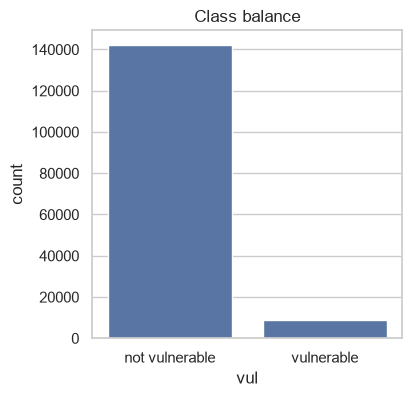

In [4]:
vul_counts = df_cpp["vul"].value_counts().sort_index()
ratio = vul_counts[0] / vul_counts[1]
print(vul_counts)
print(f"Imbalance ratio (not-vul : vul) = {ratio:.1f} : 1")

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(x=vul_counts.index.map({0: "not vulnerable", 1: "vulnerable"}), y=vul_counts.values, ax=ax)
ax.set_ylabel("count")
ax.set_title("Class balance")
plt.show()

## 4. Code length distribution

GraphCodeBERT has a max input length of 512 tokens. Character length is a
rough proxy — we'll check actual tokenized length in Phase 3/4, but this
already tells us whether most functions are short enough or if long-function
truncation will be a real concern.

count    150908.000000
mean        910.899416
std        2539.581421
min          14.000000
25%         193.000000
50%         394.000000
75%         873.000000
max      240969.000000
Name: code_len_chars, dtype: float64


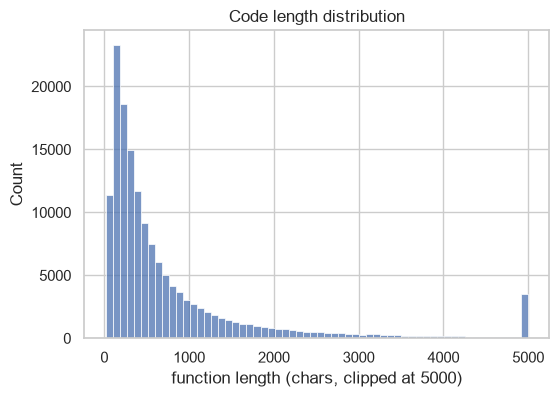

In [5]:
df_cpp["code_len_chars"] = df_cpp["func_before"].str.len()
print(df_cpp["code_len_chars"].describe())

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df_cpp["code_len_chars"].clip(upper=5000), bins=60, ax=ax)
ax.set_xlabel("function length (chars, clipped at 5000)")
ax.set_title("Code length distribution")
plt.show()

## 5. Most common vulnerability types (CWE)

Only meaningful for `vul == 1` rows — `CWE ID` is empty/NaN for non-vulnerable
functions.

CWE ID
CWE-119    1716
CWE-20      900
CWE-399     588
CWE-125     495
CWE-200     406
CWE-264     391
CWE-189     275
CWE-416     261
CWE-190     249
CWE-362     212
CWE-476     170
CWE-787     155
CWE-284     141
CWE-254     101
CWE-310      72
Name: count, dtype: int64


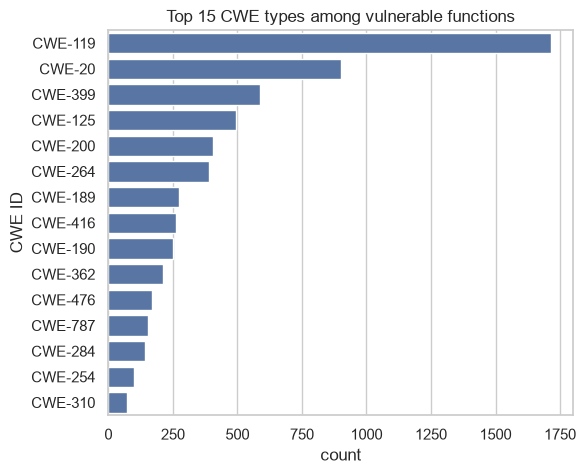

In [6]:
top_cwe = df_cpp[df_cpp["vul"] == 1]["CWE ID"].value_counts().head(15)
print(top_cwe)

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(x=top_cwe.values, y=top_cwe.index, ax=ax)
ax.set_xlabel("count")
ax.set_title("Top 15 CWE types among vulnerable functions")
plt.show()

## 6. Duplicate functions

Big-Vul has known duplicate `func_before` entries (same function appearing
across multiple CVE rows or multiple splits). Exact duplicates leaking across
train/val/test would inflate evaluation metrics, so we quantify it here and
deduplicate in Phase 3.

In [7]:
n_total = len(df_cpp)
n_unique = df_cpp["func_before"].nunique()
print(f"Total rows: {n_total}")
print(f"Unique func_before: {n_unique}")
print(f"Exact duplicate rows: {n_total - n_unique} ({(n_total - n_unique) / n_total:.1%})")

Total rows: 150908
Unique func_before: 150908
Exact duplicate rows: 0 (0.0%)


## Summary — what this means for Phase 3

- Normalize `lang` (`CPP`/`C++` → `C++`) before filtering.
- Imbalance is real (~16:1) → need weighted sampling / class weights when training.
- Some functions are very long → will need truncation strategy for the 512-token limit.
- Duplicates exist → dedupe by `func_before` before splitting, so the same function never appears in both train and test.